In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn

In [3]:
df = pd.read_csv("../data/network_telemetry_anomaly.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])

print("Shape:", df.shape)
print("Kolom:")
print(df.columns.tolist())

Shape: (20160, 9)
Kolom:
['timestamp', 'device_id', 'bandwidth', 'latency', 'packet_loss', 'cpu_usage', 'memory_usage', 'is_anomaly', 'anomaly_type']


In [4]:
normal_data = df[df["is_anomaly"] == 0].copy()
anomaly_data = df[df["is_anomaly"] == 1].copy()

print("Normal data :", len(normal_data))
print("Anomaly data:", len(anomaly_data))

Normal data : 20139
Anomaly data: 21


In [5]:
features = [
    "bandwidth",
    "latency",
    "packet_loss",
    "cpu_usage",
    "memory_usage"
]

X_normal = normal_data[features]

print("Features:", features)
print("Shape:", X_normal.shape)

Features: ['bandwidth', 'latency', 'packet_loss', 'cpu_usage', 'memory_usage']
Shape: (20139, 5)


In [6]:
from sklearn.model_selection import train_test_split

X_normal = normal_data[features]

X_train, X_val = train_test_split(
    X_normal,
    test_size=0.2,
    random_state=42
)

print("Train shape     :", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape     : (16111, 5)
Validation shape: (4028, 5)


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Train scaled shape     :", X_train_scaled.shape)
print("Validation scaled shape:", X_val_scaled.shape)

print("\nTrain mean:")
print(X_train_scaled.mean(axis=0).round(4))

print("\nTrain standard deviation:")
print(X_train_scaled.std(axis=0).round(4))

Train scaled shape     : (16111, 5)
Validation scaled shape: (4028, 5)

Train mean:
[ 0.  0.  0. -0. -0.]

Train standard deviation:
[1. 1. 1. 1. 1.]


In [8]:
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_scaled,
    dtype=torch.float32
)

print("Train tensor:", X_train_tensor.shape)
print("Validation tensor:", X_val_tensor.shape)
print("Data type:", X_train_tensor.dtype)

Train tensor: torch.Size([16111, 5])
Validation tensor: torch.Size([4028, 5])
Data type: torch.float32


In [9]:
class Autoencoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(5, 3),
            nn.ReLU(),
            nn.Linear(3, 2)
        )

        self.decoder = nn.Sequential(
            nn.Linear(2, 3),
            nn.ReLU(),
            nn.Linear(3, 5)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)

        return decoded

In [10]:
model = Autoencoder()

print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=5, out_features=3, bias=True)
    (1): ReLU()
    (2): Linear(in_features=3, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=3, bias=True)
    (1): ReLU()
    (2): Linear(in_features=3, out_features=5, bias=True)
  )
)


In [11]:
criterion = nn.MSELoss()

print("Loss function:", criterion)

Loss function: MSELoss()


In [12]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [13]:
epochs = 100

loss_history = []

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

for epoch in range(epochs):

    output = model(X_train_tensor)

    loss = criterion(
        output,
        X_train_tensor
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch + 1}/{epochs}], "
            f"Loss: {loss.item():.6f}"
        )

Epoch [10/100], Loss: 1.116280
Epoch [20/100], Loss: 1.094440
Epoch [30/100], Loss: 1.075747
Epoch [40/100], Loss: 1.059569
Epoch [50/100], Loss: 1.045167
Epoch [60/100], Loss: 1.032331
Epoch [70/100], Loss: 1.020526
Epoch [80/100], Loss: 1.009138
Epoch [90/100], Loss: 0.997845
Epoch [100/100], Loss: 0.986428


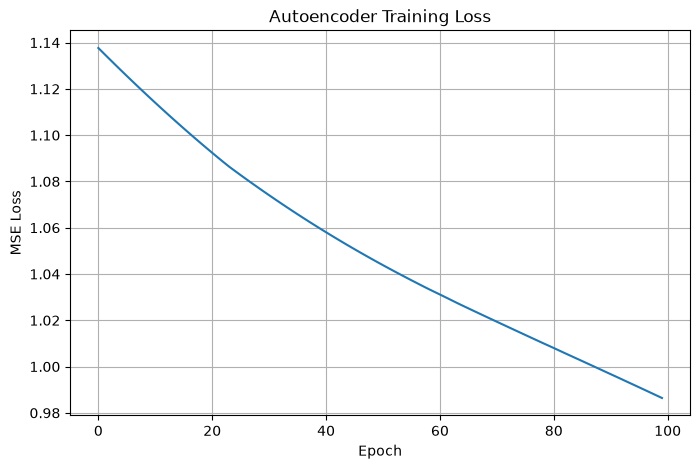

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)

plt.show()

In [15]:
X_all = df[features]

X_all_scaled = scaler.transform(X_all)

X_all_tensor = torch.tensor(
    X_all_scaled,
    dtype=torch.float32
)

print("Shape:", X_all_tensor.shape)

Shape: torch.Size([20160, 5])


In [16]:
model.eval()

with torch.no_grad():
    reconstructed = model(X_all_tensor)

print("Shape input       :", X_all_tensor.shape)
print("Shape reconstruction:", reconstructed.shape)

Shape input       : torch.Size([20160, 5])
Shape reconstruction: torch.Size([20160, 5])


In [17]:
reconstruction_error = torch.mean(
    (X_all_tensor - reconstructed) ** 2,
    dim=1
)

anomaly_scores = reconstruction_error.numpy()

print("Jumlah anomaly score:", len(anomaly_scores))
print("Min:", anomaly_scores.min())
print("Max:", anomaly_scores.max())
print("Mean:", anomaly_scores.mean())

Jumlah anomaly score: 20160
Min: 0.0031181532
Max: 361.084
Mean: 1.0804983


In [18]:
df["anomaly_score"] = anomaly_scores

print(
    df[
        [
            "timestamp",
            "device_id",
            "is_anomaly",
            "anomaly_type",
            "anomaly_score"
        ]
    ].sort_values(
        "anomaly_score",
        ascending=False
    ).head(20)
)

                timestamp device_id  is_anomaly         anomaly_type  \
10890 2026-09-03 19:30:00     R-006           1  network_degradation   
10889 2026-09-03 19:25:00     R-006           1  network_degradation   
10886 2026-09-03 19:10:00     R-006           1  network_degradation   
10884 2026-09-03 19:00:00     R-006           1  network_degradation   
10888 2026-09-03 19:20:00     R-006           1  network_degradation   
10887 2026-09-03 19:15:00     R-006           1  network_degradation   
10885 2026-09-03 19:05:00     R-006           1  network_degradation   
17113 2026-09-04 10:05:00     R-009           1         cpu_overload   
17115 2026-09-04 10:15:00     R-009           1         cpu_overload   
17114 2026-09-04 10:10:00     R-009           1         cpu_overload   
17117 2026-09-04 10:25:00     R-009           1         cpu_overload   
17112 2026-09-04 10:00:00     R-009           1         cpu_overload   
17118 2026-09-04 10:30:00     R-009           1         cpu_over

In [19]:
score_summary = (
    df.groupby("anomaly_type")["anomaly_score"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

print(score_summary)

                     count        mean      median         min         max
anomaly_type                                                              
network_degradation      7  256.538147  249.567169  168.010300  361.084015
cpu_overload             7   12.726344   12.000563   11.426538   14.565704
traffic_spike            7    5.411239    5.141082    4.307720    7.492790
normal               20139    0.986152    0.883865    0.003118    5.472435


In [20]:
normal_scores = df.loc[
    df["is_anomaly"] == 0,
    "anomaly_score"
]

threshold = np.percentile(
    normal_scores,
    95
)

print("Threshold:", threshold)

Threshold: 2.0797288


In [21]:
df["predicted_anomaly"] = (
    df["anomaly_score"] > threshold
).astype(int)

print(
    df["predicted_anomaly"].value_counts()
)

predicted_anomaly
0    19132
1     1028
Name: count, dtype: int64


In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    df["is_anomaly"],
    df["predicted_anomaly"]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[19132  1007]
 [    0    21]]


In [23]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

precision = precision_score(
    df["is_anomaly"],
    df["predicted_anomaly"]
)

recall = recall_score(
    df["is_anomaly"],
    df["predicted_anomaly"]
)

f1 = f1_score(
    df["is_anomaly"],
    df["predicted_anomaly"]
)

print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Precision: 0.0204
Recall   : 1.0000
F1-score : 0.0400


In [24]:
detection_summary = (
    df.groupby("anomaly_type")
    .agg(
        total=("is_anomaly", "count"),
        detected=("predicted_anomaly", "sum")
    )
)

detection_summary["detection_rate"] = (
    detection_summary["detected"]
    / detection_summary["total"]
)

print(detection_summary)

                     total  detected  detection_rate
anomaly_type                                        
cpu_overload             7         7        1.000000
network_degradation      7         7        1.000000
normal               20139      1007        0.050002
traffic_spike            7         7        1.000000


In [25]:
model.eval()

with torch.no_grad():
    reconstructed_val = model(X_val_tensor)

val_reconstruction_error = torch.mean(
    (X_val_tensor - reconstructed_val) ** 2,
    dim=1
)

val_scores = val_reconstruction_error.numpy()

print("Jumlah validation score:", len(val_scores))
print("Min:", val_scores.min())
print("Max:", val_scores.max())
print("Mean:", val_scores.mean())
print("Median:", np.median(val_scores))

Jumlah validation score: 4028
Min: 0.029785454
Max: 4.757989
Mean: 0.9896839
Median: 0.88023126


In [26]:
threshold = np.percentile(
    val_scores,
    95
)

print("Validation threshold:", threshold)

Validation threshold: 2.0775533


In [27]:
X_all = df[features]

X_all_scaled = scaler.transform(X_all)

X_all_tensor = torch.tensor(
    X_all_scaled,
    dtype=torch.float32
)

model.eval()

with torch.no_grad():
    reconstructed_all = model(X_all_tensor)

all_reconstruction_error = torch.mean(
    (X_all_tensor - reconstructed_all) ** 2,
    dim=1
)

df["anomaly_score_v2"] = (
    all_reconstruction_error.numpy()
)

df["predicted_anomaly_v2"] = (
    df["anomaly_score_v2"] > threshold
).astype(int)

print(
    df["predicted_anomaly_v2"].value_counts()
)

predicted_anomaly_v2
0    19125
1     1035
Name: count, dtype: int64


In [28]:
from sklearn.metrics import confusion_matrix

cm_v2 = confusion_matrix(
    df["is_anomaly"],
    df["predicted_anomaly_v2"]
)

print("Confusion Matrix V2:")
print(cm_v2)

Confusion Matrix V2:
[[19125  1014]
 [    0    21]]


In [29]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

precision_v2 = precision_score(
    df["is_anomaly"],
    df["predicted_anomaly_v2"]
)

recall_v2 = recall_score(
    df["is_anomaly"],
    df["predicted_anomaly_v2"]
)

f1_v2 = f1_score(
    df["is_anomaly"],
    df["predicted_anomaly_v2"]
)

print(f"Precision V2: {precision_v2:.4f}")
print(f"Recall V2   : {recall_v2:.4f}")
print(f"F1-score V2 : {f1_v2:.4f}")

Precision V2: 0.0203
Recall V2   : 1.0000
F1-score V2 : 0.0398


In [30]:
false_positive_data = df[
    (df["is_anomaly"] == 0) &
    (df["predicted_anomaly_v2"] == 1)
].copy()

print("Jumlah false positive:", len(false_positive_data))

print("\nRata-rata false positive:")
print(
    false_positive_data[features]
    .mean()
    .round(2)
)

print("\nRata-rata data normal:")
print(
    normal_data[features]
    .mean()
    .round(2)
)

Jumlah false positive: 1014

Rata-rata false positive:
bandwidth       55.67
latency         30.06
packet_loss      0.36
cpu_usage       34.51
memory_usage    53.46
dtype: float64

Rata-rata data normal:
bandwidth       49.18
latency         29.87
packet_loss      0.31
cpu_usage       36.39
memory_usage    50.44
dtype: float64


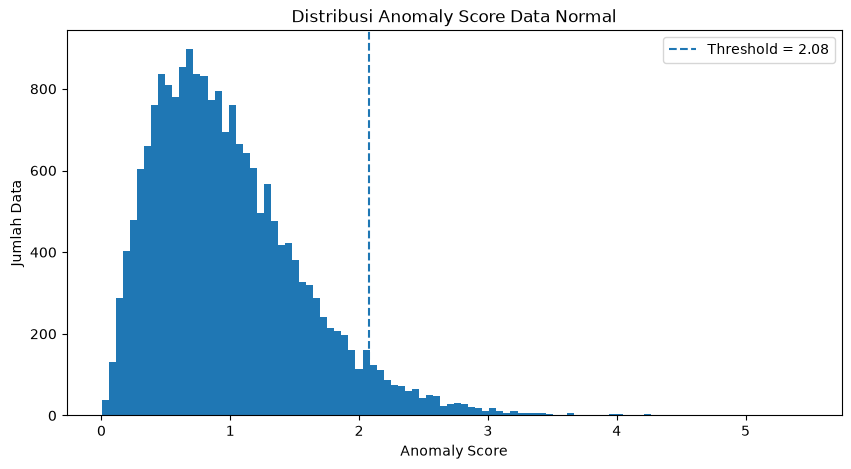

In [31]:
plt.figure(figsize=(10, 5))

plt.hist(
    df.loc[df["is_anomaly"] == 0, "anomaly_score_v2"],
    bins=100
)

plt.axvline(
    threshold,
    linestyle="--",
    label=f"Threshold = {threshold:.2f}"
)

plt.xlabel("Anomaly Score")
plt.ylabel("Jumlah Data")
plt.title("Distribusi Anomaly Score Data Normal")
plt.legend()

plt.show()

In [32]:
for percentile in [95, 97, 99, 99.5]:
    
    temp_threshold = np.percentile(
        val_scores,
        percentile
    )
    
    temp_prediction = (
        df["anomaly_score_v2"] > temp_threshold
    ).astype(int)
    
    temp_precision = precision_score(
        df["is_anomaly"],
        temp_prediction
    )
    
    temp_recall = recall_score(
        df["is_anomaly"],
        temp_prediction
    )
    
    temp_f1 = f1_score(
        df["is_anomaly"],
        temp_prediction
    )
    
    print(
        f"Percentile {percentile}% | "
        f"Threshold: {temp_threshold:.4f} | "
        f"Precision: {temp_precision:.4f} | "
        f"Recall: {temp_recall:.4f} | "
        f"F1: {temp_f1:.4f}"
    )

Percentile 95% | Threshold: 2.0776 | Precision: 0.0203 | Recall: 1.0000 | F1: 0.0398
Percentile 97% | Threshold: 2.3150 | Precision: 0.0347 | Recall: 1.0000 | F1: 0.0671
Percentile 99% | Threshold: 2.7680 | Precision: 0.0942 | Recall: 1.0000 | F1: 0.1721
Percentile 99.5% | Threshold: 2.9663 | Precision: 0.1458 | Recall: 1.0000 | F1: 0.2545


In [33]:
threshold_995 = np.percentile(
    val_scores,
    99.5
)

df["predicted_995"] = (
    df["anomaly_score_v2"] > threshold_995
).astype(int)

print("Threshold 99.5%:", threshold_995)

print("\nDeteksi berdasarkan jenis anomaly:")
print(
    df[df["is_anomaly"] == 1]
    .groupby("anomaly_type")["predicted_995"]
    .agg(["sum", "count"])
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        df["is_anomaly"],
        df["predicted_995"]
    )
)

Threshold 99.5%: 2.9663298

Deteksi berdasarkan jenis anomaly:
                     sum  count
anomaly_type                   
cpu_overload           7      7
network_degradation    7      7
traffic_spike          7      7

Confusion Matrix:
[[20016   123]
 [    0    21]]


In [34]:
from sklearn.model_selection import train_test_split

# Pecah validation data menjadi:
# 50% untuk menentukan threshold
# 50% untuk independent test normal

X_calibration, X_test_normal = train_test_split(
    X_val,
    test_size=0.5,
    random_state=42
)

print("Calibration normal :", X_calibration.shape)
print("Test normal        :", X_test_normal.shape)

Calibration normal : (2014, 5)
Test normal        : (2014, 5)


In [35]:
# Scale calibration data menggunakan scaler yang sudah di-fit pada X_train
X_calibration_scaled = scaler.transform(X_calibration)

# Ubah menjadi tensor
X_calibration_tensor = torch.tensor(
    X_calibration_scaled,
    dtype=torch.float32
)

# Hitung reconstruction error
model.eval()

with torch.no_grad():
    reconstructed_calibration = model(
        X_calibration_tensor
    )

calibration_reconstruction_error = torch.mean(
    (X_calibration_tensor - reconstructed_calibration) ** 2,
    dim=1
)

calibration_scores = (
    calibration_reconstruction_error.numpy()
)

# Threshold 99.5% dari calibration set
threshold_final = np.percentile(
    calibration_scores,
    99.5
)

print("Calibration score:")
print("Min     :", calibration_scores.min())
print("Max     :", calibration_scores.max())
print("Mean    :", calibration_scores.mean())
print("Median  :", np.median(calibration_scores))

print("\nFinal threshold (99.5%):", threshold_final)

Calibration score:
Min     : 0.029785454
Max     : 4.078582
Mean    : 0.99345946
Median  : 0.87937236

Final threshold (99.5%): 3.0311778


In [36]:
# Scale test normal
X_test_normal_scaled = scaler.transform(
    X_test_normal
)

X_test_normal_tensor = torch.tensor(
    X_test_normal_scaled,
    dtype=torch.float32
)

# Scale anomaly
X_anomaly = df[
    df["is_anomaly"] == 1
][features]

X_anomaly_scaled = scaler.transform(
    X_anomaly
)

X_anomaly_tensor = torch.tensor(
    X_anomaly_scaled,
    dtype=torch.float32
)

# Gabungkan normal test + anomaly
X_test_final = np.vstack([
    X_test_normal_scaled,
    X_anomaly_scaled
])

y_test_final = np.concatenate([
    np.zeros(len(X_test_normal)),
    np.ones(len(X_anomaly))
])

X_test_final_tensor = torch.tensor(
    X_test_final,
    dtype=torch.float32
)

# Hitung reconstruction error
model.eval()

with torch.no_grad():
    reconstructed_test = model(
        X_test_final_tensor
    )

test_reconstruction_error = torch.mean(
    (X_test_final_tensor - reconstructed_test) ** 2,
    dim=1
)

test_scores = test_reconstruction_error.numpy()

# Prediksi menggunakan threshold calibration
test_predictions = (
    test_scores > threshold_final
).astype(int)

# Evaluasi
test_precision = precision_score(
    y_test_final,
    test_predictions
)

test_recall = recall_score(
    y_test_final,
    test_predictions
)

test_f1 = f1_score(
    y_test_final,
    test_predictions
)

test_cm = confusion_matrix(
    y_test_final,
    test_predictions
)

print("FINAL TEST RESULTS")
print("==================")
print(f"Threshold : {threshold_final:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1-score  : {test_f1:.4f}")

print("\nConfusion Matrix:")
print(test_cm)

FINAL TEST RESULTS
Threshold : 3.0312
Precision : 0.7500
Recall    : 1.0000
F1-score  : 0.8571

Confusion Matrix:
[[2007    7]
 [   0   21]]


In [37]:
# Ambil anomaly dari dataset
test_anomaly_df = df[
    df["is_anomaly"] == 1
].copy()

# Ambil score anomaly dari bagian akhir test_scores
anomaly_test_scores = test_scores[
    len(X_test_normal):
]

test_anomaly_df["test_score"] = anomaly_test_scores

test_anomaly_df["predicted"] = (
    test_anomaly_df["test_score"] > threshold_final
).astype(int)

print(
    test_anomaly_df
    .groupby("anomaly_type")["predicted"]
    .agg(["sum", "count"])
)

                     sum  count
anomaly_type                   
cpu_overload           7      7
network_degradation    7      7
traffic_spike          7      7
